# =========================
# BÀI 1: ANN PHÂN LOẠI CIFAR10
# =========================

# 1. Import thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, classification_report

# 2. Load dataset CIFAR10

In [ ]:


(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


# 3. Khai báo tên class

In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# 4. Hiển thị thử vài ảnh

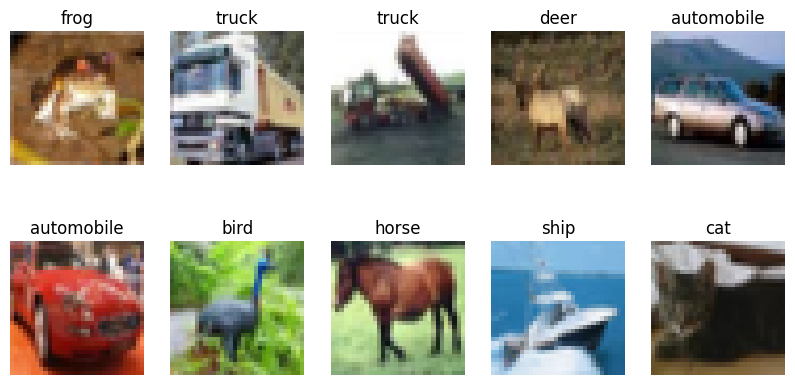

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# 5. Tiền xử lý dữ liệu

In [ ]:
# Chuyển pixel từ 0-255 về 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Chuyển label từ dạng (50000, 1) về (50000,)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

print("After processing:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

After processing:
X_train: (50000, 32, 32, 3)
y_train: (50000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)


# 6. Xây dựng mô hình ANN

In [6]:
model = Sequential()

# CIFAR10 ảnh 32x32x3, Flatten sẽ biến thành vector 3072
model.add(Flatten(input_shape=(32, 32, 3)))

model.add(Dense(
    1024,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=l2(0.0001)
))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(
    512,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=l2(0.0001)
))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(
    256,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=l2(0.0001)
))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 7. Compile model

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,812,618 (14.54 MB)

 Trainable params: 3,809,034 (14.53 MB)

 Non-trainable params: 3,584 (14.00 KB)

# 8. Huấn luyện model

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 127ms/step - accuracy: 0.3274 - loss: 2.3004 - val_accuracy: 0.2881 - val_loss: 2.3614 - learning_rate: 0.0010
Epoch 2/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.4023 - loss: 1.9942 - val_accuracy: 0.2317 - val_loss: 2.4998 - learning_rate: 0.0010
Epoch 3/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.4225 - loss: 1.8872 - val_accuracy: 0.3653 - val_loss: 1.9938 - learning_rate: 0.0010
Epoch 4/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.4301 - loss: 1.8302 - val_accuracy: 0.3845 - val_loss: 1.9183 - learning_rate: 0.0010
Epoch 5/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.4383 - loss: 1.7784 - val_accuracy: 0.3399 - val_loss: 2.0418 - learning_rate: 0.0010
Epoch 6/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.4415 - loss: 1.7462 - val_accuracy: 0.3553 - val_loss: 1.9344 - learning_rate: 0.0010
Epoch 7/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.44

# 9. Đánh giá model

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 1.2817142009735107
Test accuracy: 0.5705999732017517


# 10. Vẽ biểu đồ Accuracy

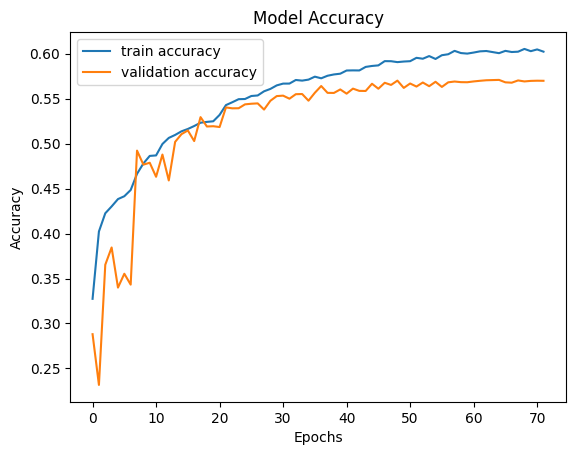

In [10]:
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 11. Vẽ biểu đồ Loss

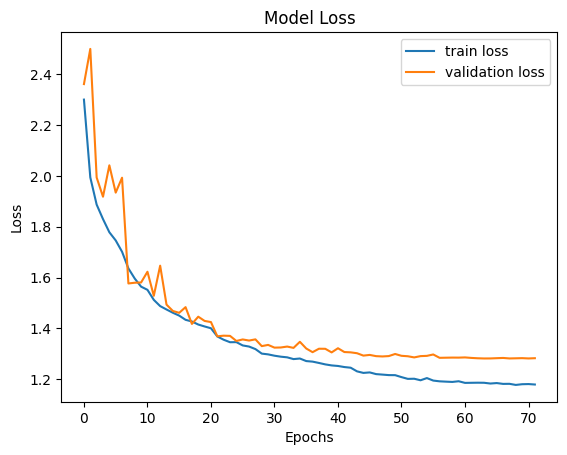

In [19]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
# 12. Dự đoán trên tập test

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted:", y_pred[:10])
print("True:", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted: [3 8 8 8 4 6 1 6 5 1]
True: [3 8 8 0 6 6 1 6 3 1]


In [20]:
# 13. In classification report

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.63      0.62      0.63      1000
  automobile       0.70      0.66      0.68      1000
        bird       0.47      0.40      0.43      1000
         cat       0.41      0.38      0.40      1000
        deer       0.50      0.51      0.51      1000
         dog       0.49      0.45      0.47      1000
        frog       0.55      0.71      0.62      1000
       horse       0.65      0.64      0.64      1000
        ship       0.65      0.72      0.69      1000
       truck       0.63      0.61      0.62      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



In [17]:
# 14. Ma trận nhầm lẫn

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[621  25  53  21  31  18  27  28 126  50]
 [ 35 657  13  22   8  16  17  21  68 143]
 [ 75  18 402  72 148  70 116  61  24  14]
 [ 21  10  79 383  57 193 154  47  29  27]
 [ 46   6 117  59 511  39 113  72  27  10]
 [ 17   8  70 211  69 449  85  56  16  19]
 [  5  12  61  52  88  41 710  14   9   8]
 [ 35   9  39  64  78  62  23 639  14  37]
 [ 85  50   7  25  19  17  14  13 725  45]
 [ 46 146   9  28  13  17  22  39  71 609]]


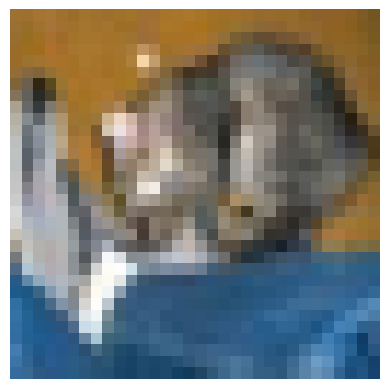

Predicted class: 3 - cat
True class: 3 - cat


In [18]:
# 15. Dự đoán thử một ảnh

index = 0

plt.imshow(X_test[index])
plt.axis("off")
plt.show()

predicted_class = y_pred[index]
true_class = y_test[index]

print("Predicted class:", predicted_class, "-", class_names[predicted_class])
print("True class:", true_class, "-", class_names[true_class])